# Heart Disease Risk Prediction: Logistic Regression

**Dataset:** Heart Disease Dataset from Kaggle (303 patients)  
**Objective:** Implement logistic regression from scratch

## Contents
1. Load & Prepare Dataset
2. Implement Logistic Regression  
3. Visualize Decision Boundaries
4. Regularization
5. SageMaker Deployment
6. Conclusions

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

print("✓ Libraries loaded")

✓ Libraries loaded


## Step 1: Load and Prepare Dataset

### Dataset Information
- **Source**: https://www.kaggle.com/datasets/neurocipher/heartdisease
- **Samples**: 303 patients
- **Features**: 14 clinical measurements
- **Target**: Heart Disease (Presence/Absence)

In [2]:
# Load dataset
df = pd.read_csv('Heart_Disease_Prediction.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst rows:")
df.head()

Dataset shape: (270, 14)

First rows:


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [3]:
# Basic EDA
print("Dataset Info:")
print(df.info())
print("\nMissing values:", df.isnull().sum().sum())
print("\nBasic statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


Class Distribution:
Heart Disease
0    150
1    120
Name: count, dtype: int64
Disease Rate: 44.4%


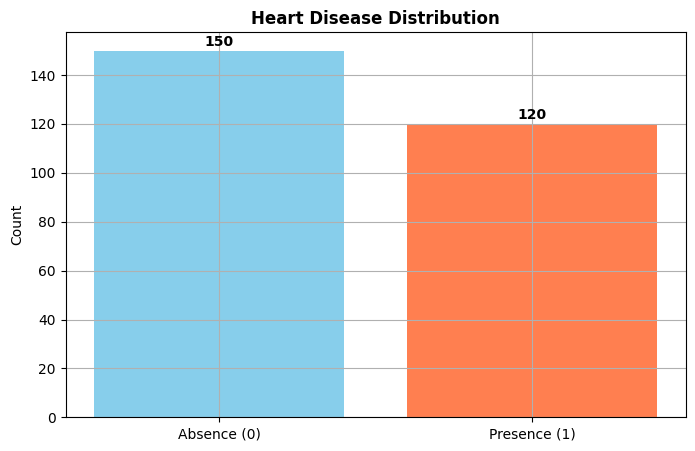

In [4]:
# Binarize target: Presence->1, Absence->0
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

# Class distribution
disease_counts = df['Heart Disease'].value_counts()
print("Class Distribution:")
print(disease_counts)
print(f"Disease Rate: {disease_counts[1]/len(df)*100:.1f}%")

# Visualize
plt.figure(figsize=(8, 5))
plt.bar(['Absence (0)', 'Presence (1)'], disease_counts.values, color=['skyblue', 'coral'])
plt.title('Heart Disease Distribution', fontweight='bold')
plt.ylabel('Count')
for i, v in enumerate(disease_counts.values):
    plt.text(i, v+2, str(v), ha='center', fontweight='bold')
plt.show()

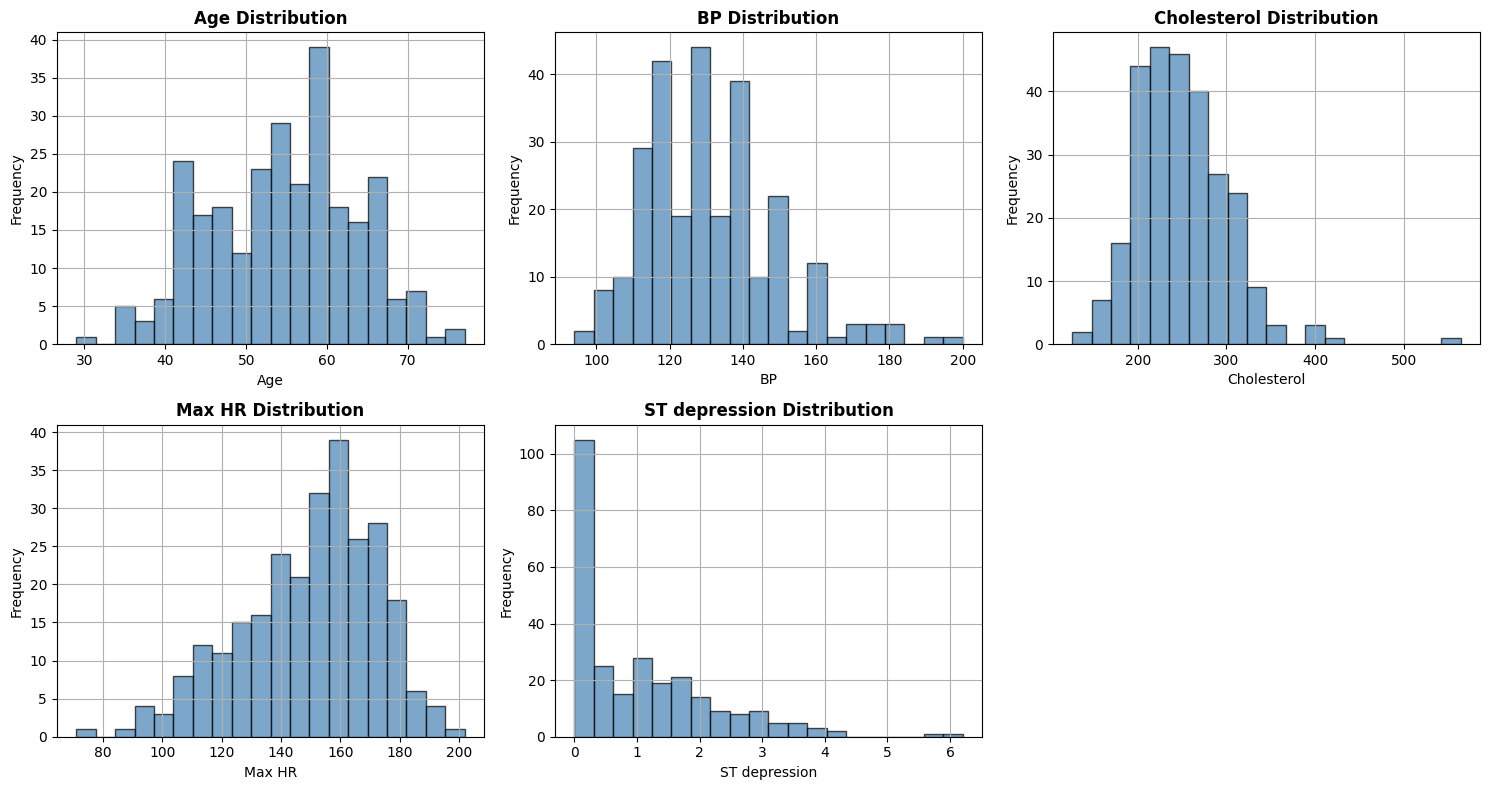

In [5]:
# Feature distributions
numerical_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    axes[idx].hist(df[feature], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{feature} Distribution', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### Prepare Data for Modeling

In [6]:
# Select features
selected_features = ['Age', 'Cholesterol', 'BP', 'Max HR', 'ST depression', 
                     'Number of vessels fluro', 'Chest pain type', 'Exercise angina']

X = df[selected_features].values
y = df['Heart Disease'].values

print(f"Selected {len(selected_features)} features:")
for i, feat in enumerate(selected_features, 1):
    print(f"{i}. {feat}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Selected 8 features:
1. Age
2. Cholesterol
3. BP
4. Max HR
5. ST depression
6. Number of vessels fluro
7. Chest pain type
8. Exercise angina

X shape: (270, 8)
y shape: (270,)


In [7]:
# Stratified train-test split (70/30)
def train_test_split_stratified(X, y, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    
    class_0_idx = np.where(y == 0)[0]
    class_1_idx = np.where(y == 1)[0]
    
    np.random.shuffle(class_0_idx)
    np.random.shuffle(class_1_idx)
    
    n_test_0 = int(len(class_0_idx) * test_size)
    n_test_1 = int(len(class_1_idx) * test_size)
    
    test_idx = np.concatenate([class_0_idx[:n_test_0], class_1_idx[:n_test_1]])
    train_idx = np.concatenate([class_0_idx[n_test_0:], class_1_idx[n_test_1:]])
    
    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)
    
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split_stratified(X, y)

print(f"Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain disease rate: {y_train.mean()*100:.2f}%")
print(f"Test disease rate: {y_test.mean()*100:.2f}%")

Training: 189 samples (70.0%)
Test: 81 samples (30.0%)

Train disease rate: 44.44%
Test disease rate: 44.44%


In [8]:
# Normalize features
def normalize_features(X_train, X_test):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1
    
    X_train_norm = (X_train - mean) / std
    X_test_norm = (X_test - mean) / std
    
    return X_train_norm, X_test_norm, mean, std

X_train_norm, X_test_norm, feature_mean, feature_std = normalize_features(X_train, X_test)

print("Features normalized (z-score)")
print(f"Train mean: {X_train_norm.mean(axis=0).round(4)}")
print(f"Train std: {X_train_norm.std(axis=0).round(4)}")

Features normalized (z-score)
Train mean: [-0. -0.  0. -0.  0. -0. -0.  0.]
Train std: [1. 1. 1. 1. 1. 1. 1. 1.]


## Step 2: Implement Logistic Regression

**Model**: $f(\vec{x}) = \sigma(\vec{w} \cdot \vec{x} + b)$  
**Sigmoid**: $\sigma(z) = \frac{1}{1+e^{-z}}$  
**Cost**: $J = -\frac{1}{m}\sum[y\log(f) + (1-y)\log(1-f)]$  
**Gradients**:  
- $\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum(f-y)x_j$
- $\frac{\partial J}{\partial b} = \frac{1}{m}\sum(f-y)$

In [9]:
# Core logistic regression functions
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def compute_cost(w, b, X, y):
    m = X.shape[0]
    z = X @ w + b
    f = sigmoid(z)
    epsilon = 1e-15
    f = np.clip(f, epsilon, 1 - epsilon)
    cost = -1/m * np.sum(y * np.log(f) + (1 - y) * np.log(1 - f))
    return cost

def compute_gradient(w, b, X, y):
    m = X.shape[0]
    z = X @ w + b
    f = sigmoid(z)
    error = f - y
    dj_dw = (1/m) * (X.T @ error)
    dj_db = (1/m) * np.sum(error)
    return dj_dw, dj_db

def gradient_descent(X, y, w_init, b_init, alpha, num_iters, print_every=0):
    w = w_init.copy()
    b = b_init
    J_history = []
    
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J = compute_cost(w, b, X, y)
        J_history.append(J)
        
        if print_every > 0 and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:5d}: Cost = {J:.6f}")
    
    return w, b, J_history

def predict(w, b, X, threshold=0.5):
    z = X @ w + b
    f = sigmoid(z)
    predictions = (f >= threshold).astype(int)
    return predictions, f

print("✓ Logistic regression functions implemented")

✓ Logistic regression functions implemented


### Train the Model

In [10]:
# Initialize and train
n_features = X_train_norm.shape[1]
w_init = np.zeros(n_features)
b_init = 0.0

alpha = 0.01
num_iters = 1000

print("Training Model...")
print(f"Learning rate: {alpha}")
print(f"Iterations: {num_iters}")
print("="*60)

w_trained, b_trained, J_history = gradient_descent(
    X_train_norm, y_train, w_init, b_init, alpha, num_iters, print_every=100
)

print("="*60)
print(f"\nFinal cost: {J_history[-1]:.6f}")
print(f"Cost reduction: {J_history[0] - J_history[-1]:.6f}")

Training Model...
Learning rate: 0.01
Iterations: 1000
Iteration     0: Cost = 0.690424
Iteration   100: Cost = 0.530755
Iteration   200: Cost = 0.471939
Iteration   300: Cost = 0.444004
Iteration   400: Cost = 0.428319
Iteration   500: Cost = 0.418495
Iteration   600: Cost = 0.411858
Iteration   700: Cost = 0.407120
Iteration   800: Cost = 0.403596
Iteration   900: Cost = 0.400890
Iteration   999: Cost = 0.398778

Final cost: 0.398778
Cost reduction: 0.291646


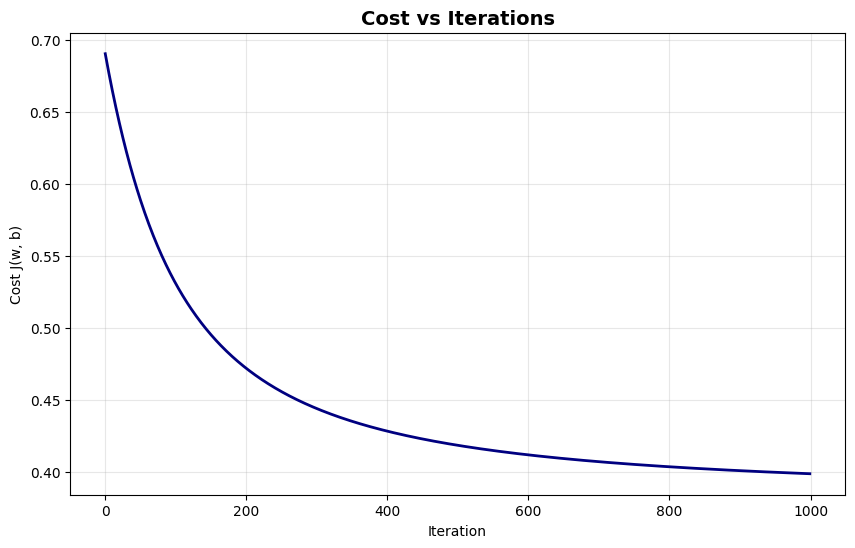

Cost decreases smoothly → successful convergence


In [11]:
# Plot cost vs iterations
plt.figure(figsize=(10, 6))
plt.plot(J_history, linewidth=2, color='navy')
plt.title('Cost vs Iterations', fontsize=14, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w, b)')
plt.grid(True, alpha=0.3)
plt.show()

print("Cost decreases smoothly → successful convergence")

### Evaluate Model

In [12]:
# Evaluation metrics
def compute_metrics(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'Accuracy': accuracy, 'Precision': precision, 
        'Recall': recall, 'F1 Score': f1,
        'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN
    }

y_train_pred, _ = predict(w_trained, b_trained, X_train_norm)
y_test_pred, _ = predict(w_trained, b_trained, X_test_norm)

train_metrics = compute_metrics(y_train, y_train_pred)
test_metrics = compute_metrics(y_test, y_test_pred)

print("="*70)
print(" "*20 + "MODEL PERFORMANCE")
print("="*70)
print(f"{'Metric':<20} {'Training':<20} {'Test':<20}")
print("-"*70)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    print(f"{metric:<20} {train_metrics[metric]*100:6.2f}%             {test_metrics[metric]*100:6.2f}%")
print("="*70)

                    MODEL PERFORMANCE
Metric               Training             Test                
----------------------------------------------------------------------
Accuracy              83.60%              81.48%
Precision             86.30%              83.87%
Recall                75.00%              72.22%
F1 Score              80.25%              77.61%
